<a href="https://colab.research.google.com/github/mxls34/AdvanceDatabase/blob/main/Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

รหัสนักศึกษา:

ชื่อ-สกุล:

# การบ้าน Chapter 1 — สำรวจฐานข้อมูล
## ตามหาตารางและความสัมพันธ์

**สถานการณ์:** คุณได้รับไฟล์ฐานข้อมูล `bookshop.duckdb` มาจากเพื่อนร่วมงาน
แต่ **ไม่มีเอกสารอธิบายใด ๆ** เลย — ไม่รู้ว่ามีตารางอะไรบ้าง เก็บอะไร เชื่อมกันยังไง

หน้าที่ของคุณคือ **สืบจากตัวฐานข้อมูลเอง** ว่า
1. มีตารางอะไรบ้าง? แต่ละตารางเก็บอะไร?
2. แต่ละตารางมีคอลัมน์อะไร ชนิดข้อมูลอะไร? Key คืออะไร?
3. ตารางเชื่อมโยงกันอย่างไร? (Foreign Key / ความสัมพันธ์)
4. วาด ER diagram จากสิ่งที่ค้นพบ
5. ลองวิเคราะห์ข้อมูลจริงด้วย JOIN



In [ ]:
# ติดตั้งและเชื่อมต่อฐานข้อมูล
!pip install duckdb --quiet

In [ ]:
import duckdb
import pandas as pd

# ก่อนรัน: อัปโหลดไฟล์ bookshop.duckdb เข้ามาก่อน
con = duckdb.connect('bookshop.duckdb', read_only=True)

def run(sql):
    try:
        return con.execute(sql).df()
    except Exception as e:
        print(f" {type(e).__name__}: {e}")

print(" เชื่อมต่อ bookshop.duckdb สำเร็จ — เริ่มค้นหาได้เลย!")


 เชื่อมต่อ bookshop.duckdb สำเร็จ — เริ่มค้นหาได้เลย!


---
# ภารกิจที่ 1 — มีตารางอะไรบ้าง?

เริ่มจากคำถามพื้นฐานที่สุด...ฐานข้อมูลนี้มีตารางอะไรบ้าง?

**คำสั่งที่ช่วยได้** `SHOW TABLES` หรือ query จาก `information_schema.tables`


In [ ]:
# ลองหารายชื่อตารางทั้งหมดในฐานข้อมูลนี้
# เขียนโค้ดของคุณที่นี่:
run("SHOW TABLES")


,name
0,author
1,book
2,category
3,customer
4,order_item
5,orders
6,review


---
# ภารกิจที่ 2 — แต่ละตารางมีคอลัมน์อะไร?

เลือกตารางมาดูโครงสร้าง — มีคอลัมน์อะไร ชนิดข้อมูลอะไร อนุญาต NULL ไหม

**คำสั่งที่ช่วยได้:** `DESCRIBE ชื่อตาราง` หรือ `information_schema.columns`


In [ ]:
# ดูโครงสร้างของตาราง book (แล้วลองดูตารางอื่นเองด้วย)
# เขียนโค้ดของคุณที่นี่:

display(con.execute("DESCRIBE book").df())

tables = con.execute("SHOW TABLES").fetchall()
# print(tables)
for table in tables:
  name = table[0]
  # print(name)
  print(f"\n{'='*25} {name} {'='*25}\n")
  display(con.execute(f"DESCRIBE {name}").df())

[('author',), ('book',), ('category',), ('customer',), ('order_item',), ('orders',), ('review',)]

========================= author =========================



,column_name,column_type,null,key,default,extra
0,author_id,INTEGER,NO,PRI,None,None
1,name,VARCHAR,NO,None,None,None
2,country,VARCHAR,YES,None,None,None



========================= book =========================



,column_name,column_type,null,key,default,extra
0,book_id,INTEGER,NO,PRI,None,None
1,title,VARCHAR,NO,None,None,None
2,isbn,VARCHAR,YES,UNI,None,None
3,price,"DECIMAL(10,2)",YES,None,None,None
4,category_id,INTEGER,YES,None,None,None
5,author_id,INTEGER,YES,None,None,None



========================= category =========================



...

,column_name,column_type,null,key,default,extra
0,order_id,INTEGER,NO,PRI,None,None
1,book_id,INTEGER,NO,PRI,None,None
2,quantity,INTEGER,YES,None,None,None
3,unit_price,"DECIMAL(10,2)",YES,None,None,None



========================= orders =========================



,column_name,column_type,null,key,default,extra
0,order_id,INTEGER,NO,PRI,None,None
1,customer_id,INTEGER,NO,None,None,None
2,order_date,DATE,NO,None,None,None
3,status,VARCHAR,YES,None,'pending',None



========================= review =========================



,column_name,column_type,null,key,default,extra
0,review_id,INTEGER,NO,PRI,None,None
1,book_id,INTEGER,NO,None,None,None
2,customer_id,INTEGER,NO,None,None,None
3,rating,INTEGER,YES,None,None,None
4,comment,VARCHAR,YES,None,None,None
5,review_date,DATE,YES,None,None,None


In [ ]:
# ต้องการดูข้อมูลตัวอย่างของแต่ละตาราง (5 แถวแรก) เพื่อเข้าใจว่าเก็บอะไร
# เขียนโค้ดของคุณที่นี่:

for table in tables:
  name = table[0]
  print(f"\n{'+' * 25} {name} {'+' * 25}\n")
  display(con.execute(f"SELECT * FROM {name} LIMIT 5").df())


+++++++++++++++++++++++++ author +++++++++++++++++++++++++



,author_id,name,country
0,1,Edgar Codd,UK
1,2,Martin Kleppmann,UK
2,3,Wes McKinney,USA
3,4,Hadley Wickham,New Zealand
4,5,George Orwell,UK



+++++++++++++++++++++++++ book +++++++++++++++++++++++++



,book_id,title,isbn,price,category_id,author_id
0,1,SQL Fundamentals,978-001,350.0,3,1
1,2,Designing Data-Intensive Apps,978-002,1200.0,3,2
2,3,Python for Data Analysis,978-003,890.0,2,3
3,4,R for Data Science,978-004,750.0,2,4
4,5,Clean Code in Python,978-005,650.0,1,3



+++++++++++++++++++++++++ category +++++++++++++++++++++++++



...

,order_id,book_id,quantity,unit_price
0,101,1,1,350.0
1,101,3,2,890.0
2,102,2,1,1200.0
3,103,3,1,890.0
4,103,4,1,750.0



+++++++++++++++++++++++++ orders +++++++++++++++++++++++++



,order_id,customer_id,order_date,status
0,101,1,2025-06-01,completed
1,102,1,2025-06-15,completed
2,103,2,2025-06-20,completed
3,104,3,2025-07-01,pending
4,105,2,2025-07-10,completed



+++++++++++++++++++++++++ review +++++++++++++++++++++++++



,review_id,book_id,customer_id,rating,comment,review_date
0,1,1,1,5,เนื้อหาดีมาก,2025-06-10
1,2,3,1,4,ละเอียดดี,2025-06-12
2,3,2,2,5,หนังสือคลาสสิก,2025-06-25
3,4,3,3,4,None,2025-07-05
4,5,1,2,3,พื้นฐานไปนิด,2025-07-15


---
# ภารกิจที่ 3 — Primary Key และ Foreign Key คืออะไร?

นี่คือหัวใจของการเข้าใจ **ความสัมพันธ์** — ตารางเชื่อมกันผ่าน Foreign Key

**คำสั่งที่ช่วยได้:** `duckdb_constraints()` — ฟังก์ชันพิเศษของ DuckDB ที่บอก constraint ทั้งหมด


In [ ]:
# หา Primary Key และ Foreign Key ทั้งหมดในฐานข้อมูล
# เขียนโค้ดของคุณที่นี่:
con.execute("SELECT * FROM duckdb_constraints()").df()


,database_name,database_oid,schema_name,schema_oid,table_name,table_oid,constraint_index,constraint_type,constraint_text,expression,constraint_column_indexes,constraint_column_names,constraint_name,referenced_table,referenced_column_names
0,bookshop,570,main,572,author,599,0,PRIMARY KEY,PRIMARY KEY(author_id),None,[0],[author_id],author_author_id_pkey,None,[]
1,bookshop,570,main,572,author,599,1,NOT NULL,NOT NULL,None,[1],[name],author_name_not_null,None,[]
2,bookshop,570,main,572,author,599,2,NOT NULL,NOT NULL,None,[0],[author_id],author_author_id_not_null,None,[]
3,bookshop,570,main,572,book,669,3,PRIMARY KEY,PRIMARY KEY(book_id),None,[0],[book_id],book_book_id_pkey,None,[]
4,bookshop,570,main,572,book,669,4,NOT NULL,NOT NULL,None,[1],[title],book_title_not_null,None,[]
5,bookshop,570,main,572,book,669,5,UNIQUE,UNIQUE(isbn),None,[2],[isbn],book_isbn_key,None,[]
6,bookshop,570,main,572,book,669,6,CHECK,CHECK((price >= 0)),(price >= 0),[3],[price],book_price_check,None,[]
7,bookshop,570,main,572,book,669,7,FOREIGN KEY,FOREIGN KEY (category_id) REFERENCES main.cate...,None,[4],[category_id],book_category_id_category_id_fkey,category,[category_id]
8,bookshop,570,main,572,book,669,8,FOREIGN KEY,FOREIGN KEY (author_id) REFERENCES main.author...,None,[5],[author_id],book_author_id_author_id_fkey,author,[author_id]
9,bookshop,570,main,572,book,669,9,NOT NULL,NOT NULL,None,[0],[book_id],book_book_id_not_null,None,[]


---
# ภารกิจที่ 4 — สรุปความสัมพันธ์และวาด ER

จาก Foreign Key ที่พบ ลองสรุปว่าแต่ละความสัมพันธ์เป็นแบบไหน (1:N หรือ M:N)

**คำถามชวนคิด:**
- ลูกค้าหนึ่งคนสั่งซื้อได้กี่ครั้ง? → ความสัมพันธ์ `customer` ↔ `orders` เป็นแบบไหน?
- ออเดอร์หนึ่งมีหนังสือได้กี่เล่ม? หนังสือหนึ่งเล่มอยู่ในกี่ออเดอร์? → `orders` ↔ `book` เป็นแบบไหน?
- ตารางไหนทำหน้าที่เป็น **junction table** (ตารางกลางของ M:N)?


In [ ]:
# เขียนโค้ดของคุณที่นี่:

# ลูกค้าหนึ่งคนมีหลายออเดอร์ได้ → customer 1:N orders
# ออเดอร์หนึ่งมีหลายเล่ม + เล่มหนึ่งอยู่หลายออเดอร์ → orders M:N book
# ตาราง order_item มีหน้าที่เป็น junction table (M:N)

### ภารกิจเพิ่มเติม — วาด ER Diagram
จากที่ค้นพบ ลองวาด ER diagram ด้วยเครื่องมือออนไลน์ (เช่น [dbdiagram.io](https://dbdiagram.io))
โดยใส่ทุกตาราง คอลัมน์ PK/FK และเส้นความสัมพันธ์พร้อม cardinality (Crow's Foot)


[Diagram Picture]()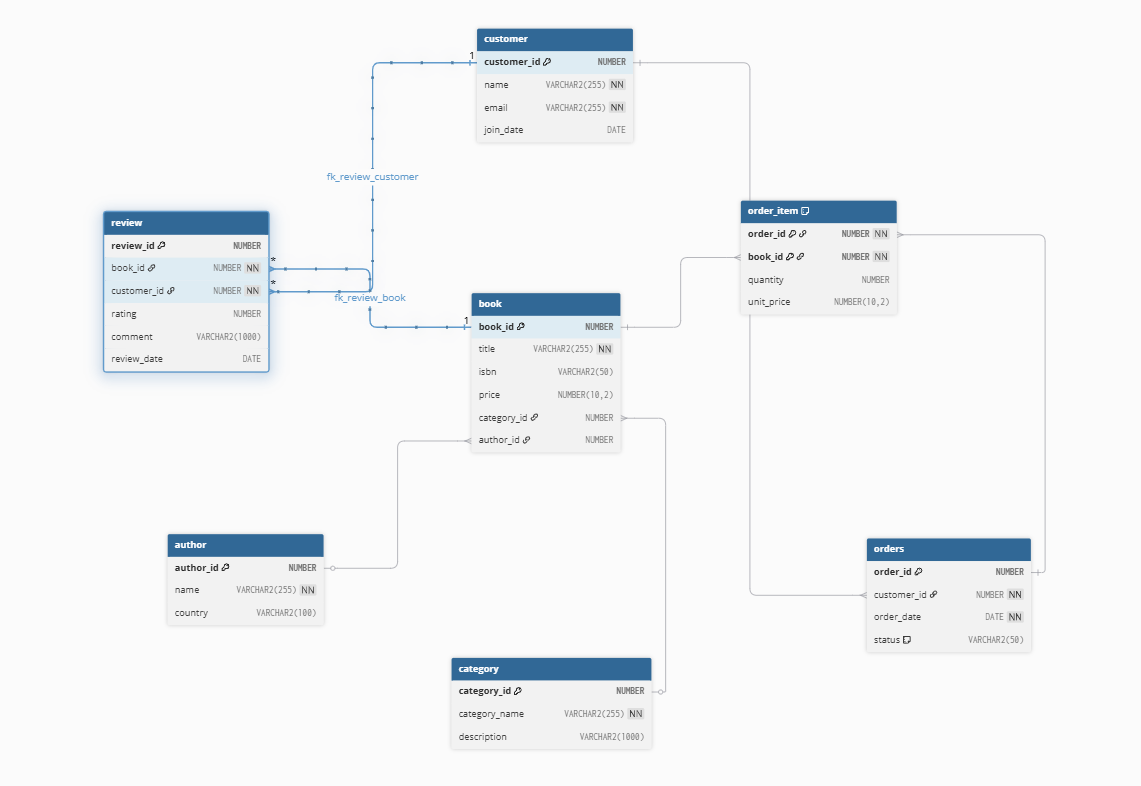

[link Diagram](https://dbdiagram.io/d/Chapter1_HW_Database_Detective-6a4e5d074ac62e474c5b46b6)

---
# ภารกิจที่ 5 — วิเคราะห์ข้อมูลด้วยการ JOIN


### คำถาม 5.1 — หนังสือแต่ละเล่มขายได้กี่เล่ม (รวมทุกออเดอร์)?
ต้อง JOIN `book` กับ `order_item`


In [ ]:
# เขียนโค้ดของคุณที่นี่:
con.execute(
    "SELECT b.title, SUM(order_item.quantity) AS totalSale FROM book b JOIN order_item ON b.book_id = order_item.book_id GROUP BY b.title"
).df()


,title,totalSale
0,SQL Fundamentals,2.0
1,Python for Data Analysis,3.0
2,1984,3.0
3,Advanced SQL,1.0
4,Designing Data-Intensive Apps,1.0
5,R for Data Science,1.0


### คำถาม 5.2 — ลูกค้าแต่ละคนใช้จ่ายรวมเท่าไหร่?
ต้อง JOIN `customer` → `orders` → `order_item` (ระวัง fan-out — ยอดเงินอยู่ที่ order_item)


In [ ]:
# เขียนโค้ดของคุณที่นี่:
print("ลูกค้าแต่ละคนใช้จ่ายรวม\n")
con.execute(
      """
        SELECT c.customer_id, c.name, SUM(order_item.quantity * order_item.unit_price) AS total_spent FROM customer c
            JOIN
                orders o ON c.customer_id = o.customer_id
            JOIN
                order_item ON o.order_id = order_item.order_id
            GROUP BY
                c.customer_id, c.name;
      """
).df()


ลูกค้าแต่ละคนใช้จ่ายรวม



,customer_id,name,total_spent
0,1,สมชาย ใจดี,3330.0
1,2,สมหญิง รักเรียน,2510.0
2,3,สมศักดิ์ ขยัน,840.0


### คำถาม 5.3 — มีลูกค้าคนไหน "ยังไม่เคยสั่งซื้อ" บ้าง?
ต้องใช้ **LEFT JOIN** + หาแถวที่ฝั่ง orders เป็น NULL (เหมือนการตรวจ orphan)


In [ ]:
# เขียนโค้ดของคุณที่นี่:

con.execute(
    "SELECT * FROM customer LEFT JOIN orders ON customer.customer_id = orders.customer_id WHERE orders.customer_id IS NULL"
).df()

,customer_id,name,email,join_date,order_id,customer_id_1,order_date,status
0,4,สมศรี ตั้งใจ,somsri@mail.com,2025-05-05,<NA>,<NA>,NaT,None


### คำถาม 5.4 — คะแนนรีวิวเฉลี่ยของหนังสือแต่ละเล่ม + ชื่อผู้แต่ง
ต้อง JOIN `book` → `author` → `review` และจัดการหนังสือที่**ยังไม่มีรีวิว**


In [ ]:
# เขียนโค้ดของคุณที่นี่:
print("\nคะแนนรีวิวเฉลี่ยของหนังสือแต่ละเล่ม และ ชื่อผู้แต่ง ที่ไม่มี NULL\n")
display(con.execute(
    """
      SELECT b.title, a.author_id, AVG(r.rating) AS avg_rating FROM book b
        JOIN author a ON b.author_id = a.author_id
        LEFT JOIN review r ON b.book_id = r.book_id WHERE r.rating NOT NULL
        GROUP BY b.title, a.author_id
    """
  ).df()
)

print("\nคะแนนรีวิวเฉลี่ยของหนังสือแต่ละเล่ม และ ชื่อผู้แต่ง ที่มีค่า NULL\n")

display(con.execute(
    """SELECT b.title, a.author_id, AVG(r.rating) AS avg_rating FROM book b
      JOIN author a ON b.author_id = a.author_id
      LEFT JOIN review r ON b.book_id = r.book_id WHERE r.rating IS NULL
      GROUP BY b.title, a.author_id"""
  ).df()
)


คะแนนรีวิวเฉลี่ยของหนังสือแต่ละเล่ม และ ชื่อผู้แต่ง ที่ไม่มี NULL



,title,author_id,avg_rating
0,Designing Data-Intensive Apps,2,5.0
1,Python for Data Analysis,3,4.0
2,SQL Fundamentals,1,4.0



คะแนนรีวิวเฉลี่ยของหนังสือแต่ละเล่ม และ ชื่อผู้แต่ง ที่มีค่า NULL



,title,author_id,avg_rating
0,R for Data Science,4,NaN
1,Clean Code in Python,3,NaN
2,1984,5,NaN
3,Advanced SQL,1,NaN
